# 02. 활성화 함수와 비선형성

활성화 함수는 선형 계산 결과에 비선형성을 추가하는 함수이다.

선형층만 여러 개 쌓으면 결국 하나의 선형 변환과 같아지므로 복잡한 패턴을 학습할 수 없다.
활성화 함수가 들어가야 신경망은 곡선 경계, 이미지 패턴, 복잡한 데이터 관계를 표현할 수 있다.

대표적인 활성화 함수에는 Step, Sigmoid, Tanh, ReLU, Leaky ReLU, Softmax가 있다.
Sigmoid와 Tanh는 값의 범위를 제한해 해석이 쉽지만, 깊은 네트워크에서는 기울기 소실 문제가 생기기 쉽다.
ReLU는 계산이 단순하고 깊은 모델에서 잘 동작해 CNN과 MLP의 은닉층에서 가장 기본적으로 사용된다.

PyTorch에서는 `torch.nn.functional` 또는 `nn.ReLU`, `nn.Sigmoid`, `nn.Softmax` 같은 모듈로 활성화 함수를 적용한다.
은닉층에서는 보통 ReLU 계열을 사용하고, 출력층에서는 문제 유형과 손실함수에 따라 sigmoid, softmax, 또는 logits 그대로를 선택한다.

이 노트북의 핵심은 활성화 함수 그래프를 외우는 것이 아니라, 각 함수가 출력 범위와 기울기 흐름을 어떻게 바꾸는지 확인하는 것이다.


# 활성화 함수 (Activation Function)

딥러닝의 **활성화 함수(Activation Function)** 란,
뉴런에서 계산된 값에 **비선형성(non-linearity)** 을 부여하여 모델이 복잡한 패턴을 학습할 수 있도록 도와주는 함수이다.

입력 신호를 받아 출력 신호로 바꿔주는 역할을 하며, 주로 은닉층과 출력층에서 사용된다.

**주요 활성화 함수 정리**

| 이름             | 수식 또는 특징                                  | 장점                        | 단점                            |
| -------------- | ----------------------------------------- | ------------------------- | ----------------------------- |
| **Sigmoid**    | `1 / (1 + exp(-x))`                       | 출력이 0\~1로 제한되어 확률처럼 해석 가능 | 기울기 소실(Vanishing Gradient) 문제 |
| **Tanh**       | `(exp(x) - exp(-x)) / (exp(x) + exp(-x))` | 출력이 -1\~1로 중심이 0          | 여전히 기울기 소실 문제 있음              |
| **ReLU**       | `max(0, x)`                               | 계산 간단, 빠름, 기울기 소실 문제 적음   | x<0이면 출력이 0이라 죽은 뉴런 발생 가능     |
| **Leaky ReLU** | `x if x>0 else αx (보통 α=0.01)`            | ReLU의 죽은 뉴런 문제 개선         | α값 선택이 임의적                    |
| **Softmax**    | `exp(xᵢ) / sum(exp(xⱼ))` (출력층에서 사용)       | 다중 클래스 분류에서 확률 출력         | 출력 간 상호의존성 있음                 |

---


> **활성화 함수가 없다면** 딥러닝 모델은 선형 함수들의 조합에 불과해 어떤 복잡한 문제도 해결하지 못한다.

### 계단 함수 (Step Function)

$ f(x) = \begin{cases} 1, & x \geq 0 \\ 0, & x < 0 \end{cases}$

- 입력값이 0 이상이면 1, 그렇지 않으면 0 출력

**✅ 계단함수가 활성화함수로 사용되지 않는 이유**
1. 미분 불가능하다
   - 역전파(backpropagation)를 위해서는 미분 가능해야 하는데, 계단함수는 0에서 불연속이기 때문에 미분이 불가능하다.
2. 출력이 이산(discrete)적이다
   - 출력이 0 또는 1만 나와서 연속적인 출력 조정이 어렵다. 이는 학습의 세밀함을 떨어뜨린다.
3. 기울기(gradient)가 0이거나 undefined
   - 대부분의 구간에서 기울기가 0이기 때문에 가중치 업데이트가 거의 일어나지 않는다. 학습이 진행되지 않는다.
4. 비선형성이 약하고 표현력이 낮다
   - 함수 자체는 비선형이지만, 실제로 모델이 복잡한 관계를 학습하기에는 표현력이 떨어진다.


#### 기본 라이브러리 불러오기


In [13]:
import numpy as np

import matplotlib.pyplot as plt

import pandas as pd


#### 계단 함수 구현과 시각화

계단 함수는 퍼셉트론처럼 기준 이상이면 1, 아니면 0을 반환하는 불연속 활성화 함수이다.


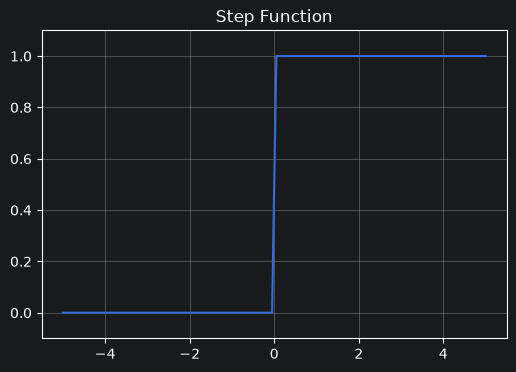

In [14]:
def step_function(x):
    return np.where(x >= 0, 1, 0)

X = np.linspace(-5, 5, 100)

plt.figure(figsize=(6, 4))
plt.plot(X, step_function(X))
plt.title("Step Function")
plt.grid(True)
plt.ylim(-0.1, 1.1)
plt.show()

### 시그모이드 함수 (Sigmoid Function)

$ f(x) = \frac{1}{1 + e^{-x}} $

- 출력 범위: (0, 1)
- 매끄러운 S자 곡선 형태로 확률 해석 가능
- 기울기 소실(Vanishing Gradient) 문제 발생 가능

#### 시그모이드 함수 구현과 시각화

시그모이드는 입력을 0과 1 사이 확률 형태로 압축하는 활성화 함수이다.


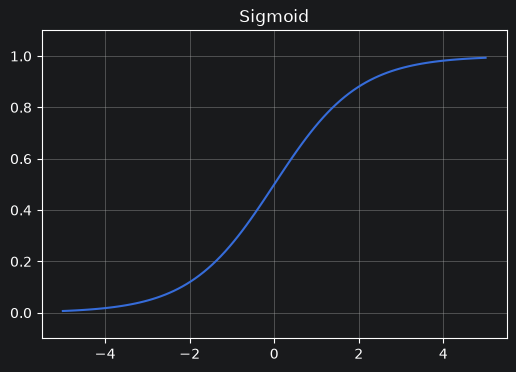

In [15]:
def sigmoid(X):
    return 1 / (1 + np.exp(-X))

plt.figure(figsize=(6, 4))
plt.plot(X, sigmoid(X))
plt.title("Sigmoid")
plt.grid(True)
plt.ylim(-0.1, 1.1)
plt.show()

### 하이퍼볼릭 탄젠트 함수 (Hyperbolic Tangent, Tanh)

$ f(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} $

- 출력 범위: (-1, 1)
- 시그모이드보다 중심이 0에 가까워 더 빠른 학습 진행 가능
- 기울기 소실 문제 발생 가능

#### 하이퍼볼릭 탄젠트 함수 구현과 시각화

tanh는 출력을 -1과 1 사이로 만들며 0 중심 값을 제공한다.


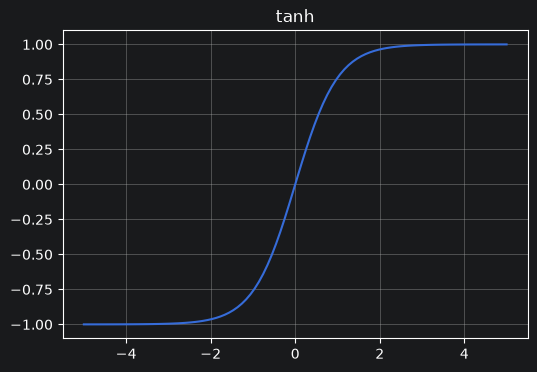

In [16]:
def tanh(X):
    # (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))
    return np.tanh(X)

plt.figure(figsize=(6, 4))
plt.plot(X, tanh(X))
plt.title("tanh")
plt.grid(True)
plt.ylim(-1.1, 1.1)
plt.show()

### ReLU (Rectified Linear Unit)

$ f(x) = \max(0, x) $

- 출력 범위: $(0, \infty)$
- 음수 입력에 대해 0을 출력하여 계산이 간단하고 학습 속도가 빠름
- 죽은 뉴런(Dying ReLU) 문제 발생 가능

#### ReLU 함수 구현과 시각화

ReLU는 양수 입력은 그대로 통과시키고 음수 입력은 0으로 자르는 활성화 함수이다.


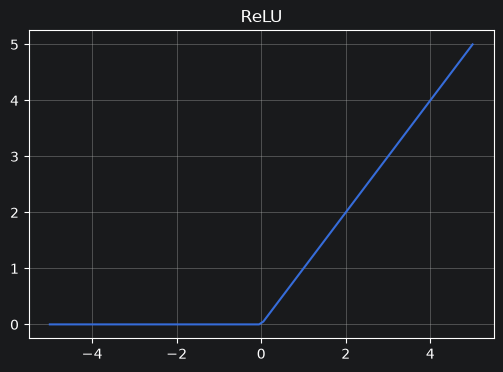

In [17]:
def relu(X):
    return np.maximum(0, X)

plt.figure(figsize=(6, 4))
plt.plot(X, relu(X))
plt.title("ReLU")
plt.grid(True)
plt.show()

### Leaky ReLU

$ f(x) = \begin{cases} x, & x \geq 0 \\ \alpha x, & x < 0\end{cases}$

- 출력 범위: $(-\infty, \infty)$
- ReLU의 죽은 뉴런 문제를 해결하기 위해 음수 입력에 작은 기울기 $\alpha$를 적용 ($\alpha$는 일반적으로 0.01 사용)

#### Leaky ReLU 함수 구현과 시각화

Leaky ReLU는 음수 구간에도 작은 기울기를 남겨 죽은 ReLU 문제를 완화한다.


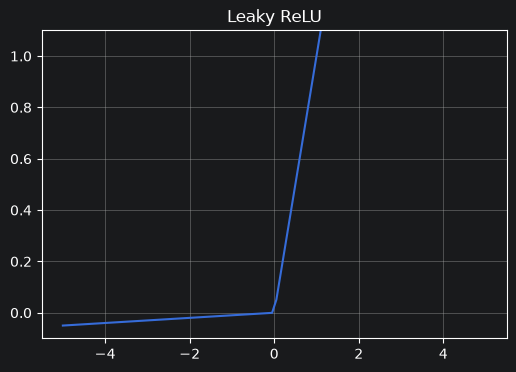

In [18]:
def leaky_relu(X, alpha=0.01):
    return np.where(X >= 0, X, alpha * X)

plt.figure(figsize=(6, 4))
plt.plot(X, leaky_relu(X))
plt.title("Leaky ReLU")
plt.grid(True)
plt.ylim(-0.1, 1.1)
plt.show()

## Softmax
softmax 함수는 **출력값들을 확률처럼 보이게** 만들어주는 함수이다.

주로 **다중 클래스 분류 문제의 출력층**에서 사용한다.

**수식** (입력 벡터 $\mathbf{z} = [z_1, z_2, ..., z_K]$ 에 대해):

$$
\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}
$$

* $z_i$는 각 클래스에 대한 점수 (logit)
* $K$는 클래스의 총 개수
* 출력값은 **0\~1 사이의 값**이며, **전체 합이 1**이 된다 → 확률처럼 해석 가능


#### Softmax 함수 구현과 시각화

Softmax는 여러 클래스 점수를 합이 1인 확률 분포로 변환한다.


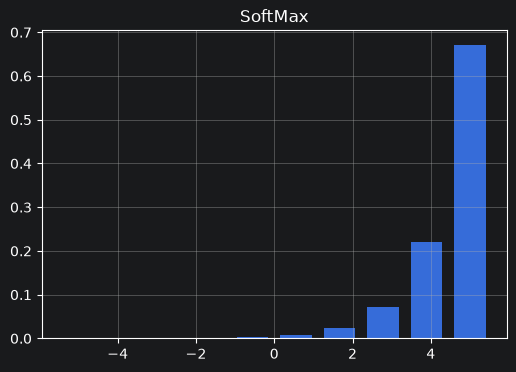

In [19]:
def softmax(X):
    exp_x = np.exp(X - np.max(X))
    return exp_x / np.sum(exp_x, axis=0)

X = np.linspace(-5, 5, 10)


plt.figure(figsize=(6, 4))
plt.bar(X, softmax(X))
plt.title("SoftMax")
plt.grid(True)
plt.show()

#### 활성화 함수 출력 비교표 만들기

같은 입력값이 활성화 함수에 따라 어떻게 다른 출력으로 바뀌는지 표로 비교한다.


In [20]:
import pandas as pd

np.random.seed(42)
# -5~5 사이 입력 10개를 뽑아 함수별 출력 차이를 비교한다.
X = np.random.uniform(-5, 5, 10) # -5 ~ 5사이 10개 숫자 샘플링

activate_df = pd.DataFrame({
    'X': X,
    'Step': step_function(X),
    'Sigmoid': sigmoid(X),
    'Tanh': tanh(X),
    'ReLU': relu(X),
    'Leaky ReLU': leaky_relu(X),
    # 입력값 순서대로 정렬하면 함수 변화 흐름을 읽기 쉽다.
}).sort_values('X')
activate_df

,X,Step,Sigmoid,Tanh,ReLU,Leaky ReLU
6,-4.419164,0,0.011901,-0.999710,0.000000,-0.044192
5,-3.440055,0,0.031067,-0.997946,0.000000,-0.034401
4,-3.439814,0,0.031074,-0.997945,0.000000,-0.034398
0,-1.254599,0,0.221905,-0.849568,0.000000,-0.012546
3,0.986585,1,0.728413,0.755902,0.986585,0.986585
8,1.011150,1,0.733245,0.766237,1.011150,1.011150
9,2.080726,1,0.889016,0.969308,2.080726,2.080726
2,2.319939,1,0.910515,0.980867,2.319939,2.319939
7,3.661761,1,0.974956,0.998681,3.661761,3.661761
1,4.507143,1,0.989090,0.999757,4.507143,4.507143


## PyTorch가 지원하는 활성화 함수

앞에서는 활성화 함수의 수식과 그래프를 NumPy로 확인했다. 이제 같은 함수를 PyTorch Tensor에 적용한다.

이 구간에서는 다음 내용만 확인한다.

- PyTorch에서 Sigmoid, Tanh, ReLU, Leaky ReLU를 사용하는 방법
- Softmax가 다른 활성화 함수와 다른 점
- 기울기 소실과 기울기 폭발의 기본 의미
- 잔차 연결이 입력을 출력에 더하는 이유


### 1. Tensor에 활성화 함수 적용하기

활성화 함수는 Tensor를 입력받아 같은 shape의 Tensor를 반환한다.

- 계산 결과만 바로 확인할 때는 `torch.sigmoid(x)`, `F.relu(x)`처럼 함수로 호출할 수 있다.
- 모델 계층으로 넣을 때는 `nn.Sigmoid()`, `nn.ReLU()`처럼 사용할 수 있다.
- 처음에는 API 종류보다 **음수, 0, 양수가 어떻게 바뀌는지**를 확인하는 것이 중요하다.


In [21]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

# 테스트용 입력값(X)
activation_input = torch.tensor([-2.0, 0.0, 2.0])

# 각 함수는 입력과 같은 shape의 Tensor를 반환한다.
activation_outputs = {
    "Sigmoid": torch.sigmoid(activation_input),
    "Tanh": torch.tanh(activation_input),
    "ReLU": F.relu(activation_input),
    # negative_slope=0.01은 음수 값을 1%만 남긴다는 뜻.
    "Leaky ReLU": F.leaky_relu(
        activation_input,
        negative_slope=0.01,
    ),
}

print("입력:", activation_input)

for name, output in activation_outputs.items():
    print(f"{name:11s}:", output)

입력: tensor([-2.,  0.,  2.])
Sigmoid    : tensor([0.1192, 0.5000, 0.8808])
Tanh       : tensor([-0.9640,  0.0000,  0.9640])
ReLU       : tensor([0., 0., 2.])
Leaky ReLU : tensor([-0.0200,  0.0000,  2.0000])


#### 결과를 읽는 방법

- **Sigmoid**: 값을 0과 1 사이로 바꾼다.
- **Tanh**: 값을 -1과 1 사이로 바꾼다.
- **ReLU**: 음수는 0, 양수는 그대로 반환한다.
- **Leaky ReLU**: 음수를 완전히 0으로 만들지 않고 작은 값으로 남긴다.

### 2. Softmax는 클래스 점수를 확률로 바꾼다

Softmax는 각 숫자를 독립적으로 바꾸는 함수가 아니다. 여러 클래스 점수를 함께 비교해 합이 1인 확률 분포로 만든다.

분류 모델의 출력 shape가 `(batch, classes)`라면 보통 `dim=1`을 사용한다. 이는 각 샘플에서 클래스 방향으로 확률을 계산한다는 뜻이다.


In [22]:
logits = torch.tensor([[2.0, 1.0, 0.1]])
# shape는 (batch=1, classes=3)이다.

# dim=1은 세 클래스가 있는 열 방향으로 Softmax를 계산한다는 뜻이다.
probabilities = F.softmax(logits, dim=1)

print("logits:", logits)
print("확률:", probabilities)
print("확률 합:", probabilities.sum(dim=1))
print("예측 클래스:", probabilities.argmax(dim=1))

logits: tensor([[2.0000, 1.0000, 0.1000]])
확률: tensor([[0.6590, 0.2424, 0.0986]])
확률 합: tensor([1.0000])
예측 클래스: tensor([0])


### 3. 기울기 소실과 기울기 폭발

**기울기**는 손실을 줄이려면 가중치를 어느 방향으로 바꿔야 하는지 알려 주는 값이다.

역전파에서는 여러 층의 미분값이 계속 곱해진다.

- 작은 값이 반복해서 곱해져 기울기가 0에 가까워지는 현상이 **기울기 소실**이다.
- 큰 값이 반복해서 곱해져 기울기가 지나치게 커지는 현상이 **기울기 폭발**이다.

Sigmoid의 기울기는 최대 0.25이다. Sigmoid를 여러 번 통과하면 입력까지 전달되는 기울기가 빠르게 작아질 수 있다.

다음 코드는 입력값 하나에 Sigmoid를 여러 번 적용하고, 마지막 출력에서 최초 입력까지의 기울기를 `backward()`로 계산한다.


In [23]:
def measure_sigmoid_gradient(depth):
    # 숫자 하나를 사용해 계산 과정을 단순하게 만듦
    # requires_grad=True는 이 입력에 대한 기울기를 계산하겠다는 뜻
    input_value = torch.tensor(1.0, requires_grad=True)
    output = input_value

    # 이전 층의 출력이 다음 층의 입력이 되는 상황을 단순화한 반복
    for _ in range(depth):
        output = torch.sigmoid(output)

    # 마지막 출력에서 최초 입력까지의 기울기를 계산
    output.backward()

    # input_value.grad에 계산된 기울기가 저장
    return output.item(), input_value.grad.item()


for depth in [1, 5, 10]:
    output_value, input_gradient = measure_sigmoid_gradient(depth)

    print(
        f"깊이={depth:2d}, "
        f"마지막 출력={output_value:.6f}, "
        f"최초 입력 기울기={input_gradient:.10f}"
    )

깊이= 1, 마지막 출력=0.731059, 최초 입력 기울기=0.1966119260
깊이= 5, 마지막 출력=0.659227, 최초 입력 기울기=0.0004861425
깊이=10, 마지막 출력=0.659046, 최초 입력 기울기=0.0000002785


### 4. 활성화 함수의 기울기 비교

활성화 함수별 기울기는 다음 특징만 기억하면 된다.

- Sigmoid와 Tanh는 입력의 절댓값이 커지면 기울기가 0에 가까워진다.
- ReLU는 양수 구간의 기울기가 1이고 음수 구간의 기울기가 0이다.
- Leaky ReLU는 음수 구간에도 작은 기울기를 남긴다.

아래 코드는 미분 공식을 PyTorch Tensor 연산으로 계산해 그래프로 보여 준다.


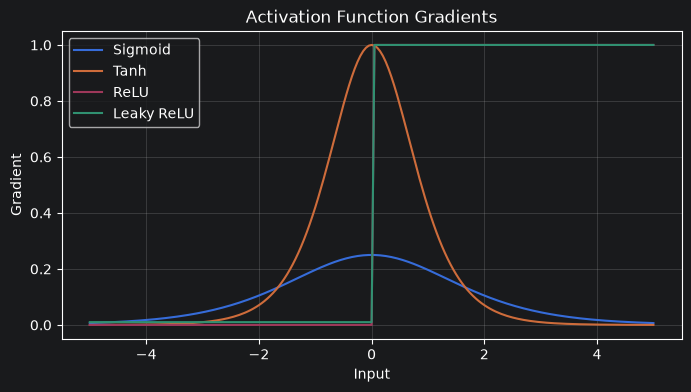

In [24]:
derivative_input = torch.linspace(-5, 5, steps=201)

# Sigmoid 미분: sigmoid(x) * (1 - sigmoid(x))
sigmoid_value = torch.sigmoid(derivative_input)
sigmoid_gradient = sigmoid_value * (1 - sigmoid_value)

# Tanh 미분: 1 - tanh(x)^2
tanh_value = torch.tanh(derivative_input)
tanh_gradient = 1 - tanh_value**2

# ReLU는 양수에서 1, 음수와 0에서 0으로 본다.
relu_gradient = torch.where(
    derivative_input > 0,
    torch.ones_like(derivative_input),
    torch.zeros_like(derivative_input),
)

# Leaky ReLU는 음수 구간에서 negative_slope만큼의 기울기를 남긴다.
leaky_relu_gradient = torch.where(
    derivative_input > 0,
    torch.ones_like(derivative_input),
    torch.full_like(derivative_input, 0.01),
)

plt.figure(figsize=(8, 4))
plt.plot(derivative_input.numpy(), sigmoid_gradient.numpy(), label="Sigmoid")
plt.plot(derivative_input.numpy(), tanh_gradient.numpy(), label="Tanh")
plt.plot(derivative_input.numpy(), relu_gradient.numpy(), label="ReLU")
plt.plot(
    derivative_input.numpy(),
    leaky_relu_gradient.numpy(),
    label="Leaky ReLU",
)

plt.xlabel("Input")
plt.ylabel("Gradient")
plt.title("Activation Function Gradients")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 5. 기울기 문제를 줄이는 기본 방법

처음에는 다음 세 가지만 기억한다.

- 은닉층에서 Sigmoid 대신 ReLU 계열을 사용하면 기울기 소실을 줄이는 데 도움이 된다.
- ReLU 뉴런이 음수 구간에서 멈추는 문제가 있으면 Leaky ReLU를 고려할 수 있다.
- 매우 깊은 모델에서는 잔차 연결을 사용해 입력이 우회하는 경로를 만든다.

기울기 폭발은 학습률 조정이나 gradient clipping 등도 함께 사용하지만, 여기서는 개념만 확인한다.


### 6. 잔차 연결

일반 계층은 `y = F(x)`를 계산한다. 잔차 연결은 `y = F(x) + x`를 계산한다.

입력 `x`를 출력에 직접 더하면 여러 층을 모두 통과하지 않는 경로가 생긴다. 입력과 변환 결과를 더하려면 두 Tensor의 shape가 같아야 한다.


In [25]:
class SimpleResidualBlock(nn.Module):
    def __init__(self, features):
        super().__init__()

        # 입력과 출력 특성 수를 같게 만들어 덧셈이 가능하게 한다.
        self.linear = nn.Linear(features, features)
        self.activation = nn.ReLU()

    def forward(self, x):
        # transformed가 F(x)에 해당한다.
        transformed = self.activation(self.linear(x))

        # 입력 x를 변환 결과에 더하는 부분이 skip connection이다.
        return x + transformed


torch.manual_seed(42)

residual_block = SimpleResidualBlock(features=3)
sample_input = torch.randn(1, 3)
sample_output = residual_block(sample_input)

print("입력 shape:", sample_input.shape)
print("출력 shape:", sample_output.shape)
print("입력:", sample_input)
print("출력:", sample_output)

입력 shape: torch.Size([1, 3])
출력 shape: torch.Size([1, 3])
입력: tensor([[ 2.2082, -0.6380,  0.4617]])
출력: tensor([[2.3912, 1.1695, 0.4617]], grad_fn=<AddBackward0>)


### 핵심 정리

- Sigmoid, Tanh, ReLU, Leaky ReLU는 Tensor의 각 원소에 적용된다.
- Softmax는 여러 클래스 점수를 합이 1인 확률로 변환한다.
- 깊은 네트워크에서는 작은 미분값이 반복해서 곱해져 기울기 소실이 발생할 수 있다.
- ReLU 계열은 깊은 은닉층의 기본 선택으로 많이 사용된다.
- 잔차 연결은 `F(x) + x` 구조로 입력이 우회하는 경로를 만든다.

### 확인 질문

1. ReLU와 Leaky ReLU는 음수 입력을 어떻게 다르게 처리하는가?
2. Softmax에서 `dim=1`은 어떤 방향을 의미하는가?
3. `loss.backward()`와 `optimizer.step()`의 역할은 어떻게 다른가?


## 선택 심화: 일반 모델과 잔차 모델의 기울기 비교

이 실습은 두 모델의 정확도를 비교하는 실습이 아니다. `loss.backward()`로 만든 학습 신호가 입력에 가까운 층까지 얼마나 전달되는지 관찰하는 실험이다.

- `nn.ModuleList`는 반복해서 사용할 여러 계층을 PyTorch 모델의 하위 계층으로 등록한다.
- `layer.weight.grad`에는 해당 `Linear` 계층의 가중치 기울기가 저장된다.
- `.norm()`은 가중치마다 존재하는 여러 기울기를 하나의 크기로 요약한다.
- Layer 1은 입력에 가장 가까운 층이고, 마지막 Layer는 출력에 가장 가까운 층이다.
- `optimizer.step()`을 실행하지 않으므로 가중치를 바꾸는 실제 학습은 아니다.

원본 코드에서는 두 모델이 서로 다른 임의 가중치로 시작한다. 아래 실습은 잔차 연결의 영향에 더 집중할 수 있도록 두 모델에 같은 초기 가중치와 같은 입력·정답을 사용한다. 그래도 두 모델의 출력과 손실은 서로 다를 수 있으므로, 기울기의 절댓값만으로 어느 모델이 더 좋다고 결론 내리면 안 된다.


In [26]:
torch.manual_seed(42)

gradient_width = 10

gradient_depth = 10


In [27]:
torch.manual_seed(7)

gradient_x = torch.randn(1, gradient_width)

gradient_y = torch.randn(1, gradient_width)
